In [1]:
# Imports
import pandas as pd
import numpy as np


In [2]:
# Load train and validation sets, parsing Time as datetime
train_df = pd.read_csv('../Data/train.csv')
val_df = pd.read_csv('../Data/val.csv')

train_df['Time'] = pd.to_datetime(train_df['Time'], format='mixed', errors='coerce')
val_df['Time'] = pd.to_datetime(val_df['Time'], format='mixed', errors='coerce')


In [3]:
# Sort by Time to guarantee chronological order before creating lag features
train_df = train_df.sort_values('Time').reset_index(drop=True)
val_df = val_df.sort_values('Time').reset_index(drop=True)


In [ ]:
# Create lag and rolling features from Power[kW] on each DataFrame separately
dfs = [train_df, val_df]
for df in dfs:
    df['power_lag1'] = df['Power[kW]'].shift(1)
    df['power_lag2'] = df['Power[kW]'].shift(2)
    df['power_lag4'] = df['Power[kW]'].shift(4)
    df['power_roll4'] = df['Power[kW]'].rolling(window=4).mean()
    

# horizons in units of 15-minute steps: 1=15min, 2=30min, ..., 8=2hours
horizon_steps = {1: '15min', 2: '30min', 3: '45min', 4: '1hour',
                  5: '75min', 6: '90min', 7: '105min', 8: '2hour'}

In [12]:
# Create forecasting targets for the 15-minute and 1-hour horizons
for df in dfs:
    for steps, label in horizon_steps.items():
        df[f'target_{label}'] = df['Power[kW]'].shift(-steps)


### Null out lag/target values that cross a time gap (not exactly 15 min)

In [24]:
for df in dfs:
   
    gap_back1 = df['Time'].diff(1)
    df.loc[gap_back1 != pd.Timedelta('15min'), 'power_lag1'] = np.nan

    
    gap_back2 = df['Time'].diff(2)
    df.loc[gap_back2 != pd.Timedelta('30min'), 'power_lag2'] = np.nan

  
    gap_back4 = df['Time'].diff(4)
    df.loc[gap_back4 != pd.Timedelta('60min'), 'power_lag4'] = np.nan
    df.loc[gap_back4 != pd.Timedelta('60min'), 'power_roll4'] = np.nan


for df in dfs:
    for steps, label in horizon_steps.items():
        gap_fwd = -df['Time'].diff(-steps)
        expected_gap = pd.Timedelta(minutes=15 * steps)
        df.loc[gap_fwd != expected_gap, f'target_{label}'] = np.nan

In [25]:
# Drop rows with NaN values created by the lag/shift operations
train_rows_before = len(train_df)
val_rows_before = len(val_df)

train_df = train_df.dropna().reset_index(drop=True)
val_df = val_df.dropna().reset_index(drop=True)

train_rows_after = len(train_df)
val_rows_after = len(val_df)

print('Train rows before:', train_rows_before, 'after:', train_rows_after)
print('Val rows before:', val_rows_before, 'after:', val_rows_after)


Train rows before: 48363 after: 48363
Val rows before: 12003 after: 12003


In [27]:
# Verify alignment: target_15min at row N equals Power[kW] at row N+1, target_1hour at row N equals Power[kW] at row N+4
check_cols = ['Time', 'Power[kW]', 'power_lag1', 'target_15min', 'target_1hour']
print(train_df[check_cols].head(6))


                 Time  Power[kW]  power_lag1  target_15min  target_1hour
0 2017-01-01 08:15:00      0.132       0.020         0.176         0.332
1 2017-01-01 08:30:00      0.176       0.132         0.244         0.276
2 2017-01-01 08:45:00      0.244       0.176         0.260         0.392
3 2017-01-01 09:00:00      0.260       0.244         0.332         0.552
4 2017-01-01 09:15:00      0.332       0.260         0.276         0.644
5 2017-01-01 09:30:00      0.276       0.332         0.392         0.476


In [28]:
# Regression metrics helper
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_report(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{label}  RMSE={rmse:,.3f}  MAE={mae:,.3f}  R2={r2:.3f}')
    return rmse, mae, r2


In [29]:
# Persistence baseline: predict the future value as the current Power[kW]
persistence_pred_15min = val_df['Power[kW]']
persistence_pred_1hour = val_df['Power[kW]']

rmse_15min, mae_15min, r2_15min = regression_report(val_df['target_15min'], persistence_pred_15min, label='15-min persistence baseline')
rmse_1hour, mae_1hour, r2_1hour = regression_report(val_df['target_1hour'], persistence_pred_1hour, label='1-hour persistence baseline')


15-min persistence baseline  RMSE=1.992  MAE=1.135  R2=0.842
1-hour persistence baseline  RMSE=3.268  MAE=2.253  R2=0.552


In [30]:
# Save the prepared forecasting datasets
train_df.to_csv('../Data/train_forecast.csv', index=False)
val_df.to_csv('../Data/val_forecast.csv', index=False)


In [31]:
# Print final shape and column list for both saved DataFrames
print('train_forecast shape:', train_df.shape)
print('train_forecast columns:', list(train_df.columns))
print('val_forecast shape:', val_df.shape)
print('val_forecast columns:', list(val_df.columns))


train_forecast shape: (48363, 31)
train_forecast columns: ['Time', 'GHI', 'temp', 'pressure', 'humidity', 'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_type', 'sunlightTime', 'dayLength', 'SunlightTime/daylength', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'isSun', 'Power[kW]', 'target_15min', 'target_30min', 'target_45min', 'target_1hour', 'target_75min', 'target_90min', 'target_105min', 'target_2hour', 'power_lag1', 'power_lag2', 'power_lag4', 'power_roll4']
val_forecast shape: (12003, 31)
val_forecast columns: ['Time', 'GHI', 'temp', 'pressure', 'humidity', 'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_type', 'sunlightTime', 'dayLength', 'SunlightTime/daylength', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'isSun', 'Power[kW]', 'target_15min', 'target_30min', 'target_45min', 'target_1hour', 'target_75min', 'target_90min', 'target_105min', 'target_2hour', 'power_lag1', 'power_lag2', 'power_lag4', 'power_roll4']


In [32]:
from sklearn.linear_model import LinearRegression


features_forecast = ['GHI', 'temp', 'pressure', 'humidity', 'wind_speed',
                      'rain_1h', 'snow_1h', 'clouds_all', 'dayLength',
                      'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                      'Power[kW]', 'power_lag1', 'power_lag2', 'power_lag4', 'power_roll4']

X_train = train_df[features_forecast]
X_val = val_df[features_forecast]


results = []
for steps, label in horizon_steps.items():
    y_train_h = train_df[f'target_{label}']
    y_val_h = val_df[f'target_{label}']

    # persistence baseline
    pers_rmse, pers_mae, pers_r2 = regression_report(
        y_val_h, val_df['Power[kW]'], label=f'Persistence {label}')

    # linear regression
    lr_h = LinearRegression().fit(X_train, y_train_h)
    lr_rmse, lr_mae, lr_r2 = regression_report(
        y_val_h, lr_h.predict(X_val), label=f'LR {label}')

    results.append({'horizon': label, 
                     'persistence_MAE': pers_mae, 'LR_MAE': lr_mae,
                     'persistence_R2': pers_r2, 'LR_R2': lr_r2})

results_df = pd.DataFrame(results)
print(results_df)

Persistence 15min  RMSE=1.992  MAE=1.135  R2=0.842
LR 15min  RMSE=1.803  MAE=1.144  R2=0.870
Persistence 30min  RMSE=2.539  MAE=1.581  R2=0.739
LR 30min  RMSE=2.208  MAE=1.498  R2=0.802
Persistence 45min  RMSE=2.910  MAE=1.931  R2=0.651
LR 45min  RMSE=2.442  MAE=1.725  R2=0.754
Persistence 1hour  RMSE=3.268  MAE=2.253  R2=0.552
LR 1hour  RMSE=2.633  MAE=1.924  R2=0.709
Persistence 75min  RMSE=3.637  MAE=2.574  R2=0.437
LR 75min  RMSE=2.798  MAE=2.097  R2=0.667
Persistence 90min  RMSE=3.974  MAE=2.880  R2=0.321
LR 90min  RMSE=2.929  MAE=2.234  R2=0.631
Persistence 105min  RMSE=4.323  MAE=3.174  R2=0.191
LR 105min  RMSE=3.047  MAE=2.365  R2=0.598
Persistence 2hour  RMSE=4.652  MAE=3.456  R2=0.061
LR 2hour  RMSE=3.140  MAE=2.466  R2=0.572
  horizon  persistence_MAE    LR_MAE  persistence_R2     LR_R2
0   15min         1.134842  1.143901        0.841563  0.870220
1   30min         1.581426  1.498367        0.738619  0.802318
2   45min         1.930882  1.724549        0.650889  0.754101
3 

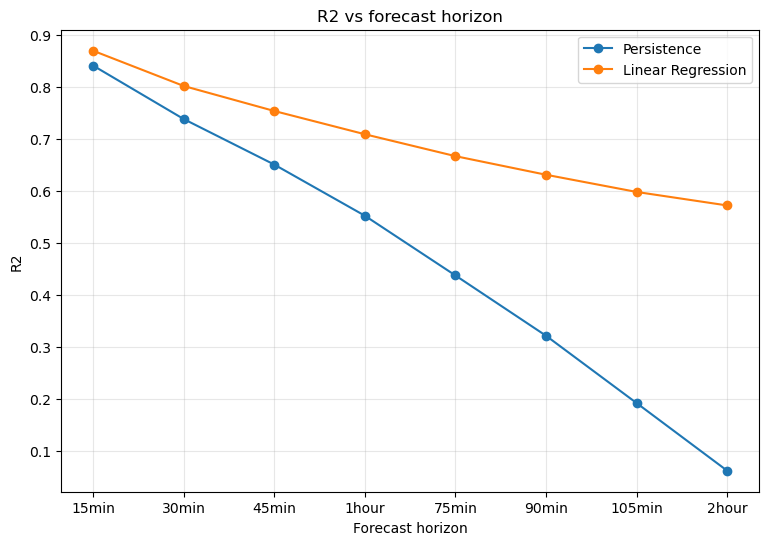

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.plot(results_df['horizon'], results_df['persistence_R2'], marker='o', label='Persistence')
plt.plot(results_df['horizon'], results_df['LR_R2'], marker='o', label='Linear Regression')
plt.xlabel('Forecast horizon')
plt.ylabel('R2')
plt.title('R2 vs forecast horizon')
plt.legend()
plt.grid(alpha=0.3)
plt.show()